In [3]:
import fiftyone as fo
import pandas as pd

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

In [ ]:
# dataset
dataset = fo.zoo.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["detections"],
    classes=["Cat", "Dog","Bird"],
    only_matching=True,
    max_samples=1000,
)

In [ ]:
print(dataset)

In [ ]:
# save dataset
dataset.persistent = True
dataset.save()

In [ ]:
del dataset

In [4]:
# load dataset
dataset = fo.load_dataset("open-images-v7-train-1000")


In [5]:
# show the labels and the bounding boxes
for sample in dataset:
    print("Image path:", sample.filepath)
    detections = sample.ground_truth.detections
    for det in detections:
        print(f"Label: {det.label}, BBox: {det.bounding_box}")

Image path: C:\Users\miste\fiftyone\open-images-v7\train\data\0000b9fcba019d36.jpg
Label: Dog, BBox: [0.165, 0.268333, 0.73875, 0.73]
Image path: C:\Users\miste\fiftyone\open-images-v7\train\data\0000cb13febe0138.jpg
Label: Dog, BBox: [0.0, 0.0, 0.651875, 0.999062]
Image path: C:\Users\miste\fiftyone\open-images-v7\train\data\0000de486dc6c49f.jpg
Label: Cat, BBox: [0.019608, 0.02451, 0.978758, 0.952614]
Image path: C:\Users\miste\fiftyone\open-images-v7\train\data\0001be3e7d78372e.jpg
Label: Bird, BBox: [0.456875, 0.441667, 0.38500000000000006, 0.305]
Image path: C:\Users\miste\fiftyone\open-images-v7\train\data\000256419f7c57d8.jpg
Label: Dog, BBox: [0.190625, 0.53, 0.11062500000000003, 0.12]
Label: Dog, BBox: [0.45, 0.485833, 0.11249999999999999, 0.11249999999999999]
Label: Dog, BBox: [0.55875, 0.515, 0.05687500000000001, 0.07750000000000001]
Label: Dog, BBox: [0.68375, 0.496667, 0.02750000000000008, 0.08583299999999999]
Label: Dog, BBox: [0.7175, 0.4775, 0.03249999999999997, 0.07416

In [ ]:
# built-in display from fiftyone
session = fo.launch_app(dataset, remote=True)


In [6]:
def show_sample(sample):
    img = Image.open(sample.filepath)
    width, height = img.size

    fig, ax = plt.subplots(1)
    ax.imshow(img)

    detections = sample.ground_truth.detections
    for det in detections:
        label = det.label
        x, y, w, h = det.bounding_box  # normalized coordinates

        # Convert to absolute pixel values
        xmin = x * width
        ymin = y * height
        box_width = w * width
        box_height = h * height

        rect = patches.Rectangle((xmin, ymin), box_width, box_height,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, label, color='white', fontsize=10,
                bbox=dict(facecolor='red', alpha=0.5))

    plt.axis('off')
    plt.show()

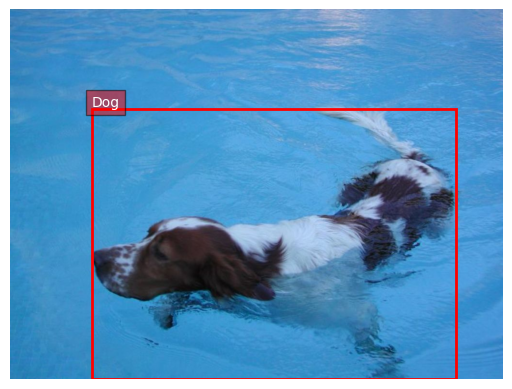

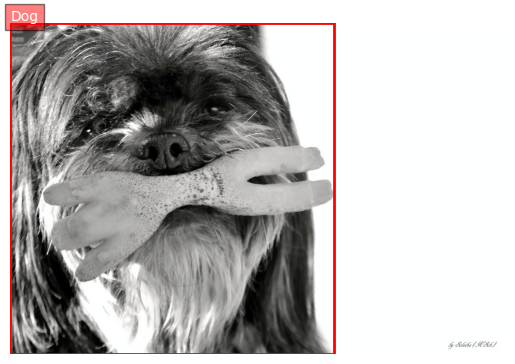

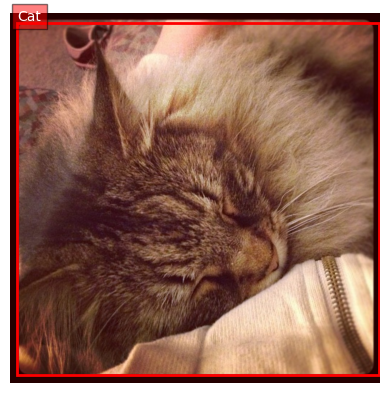

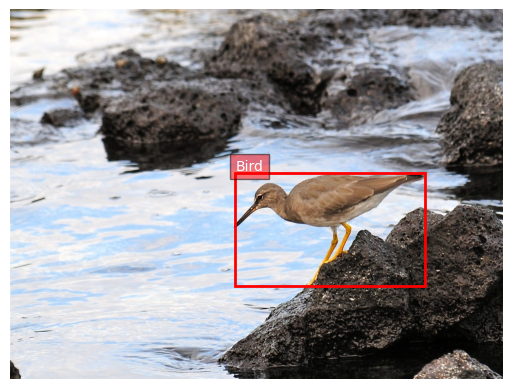

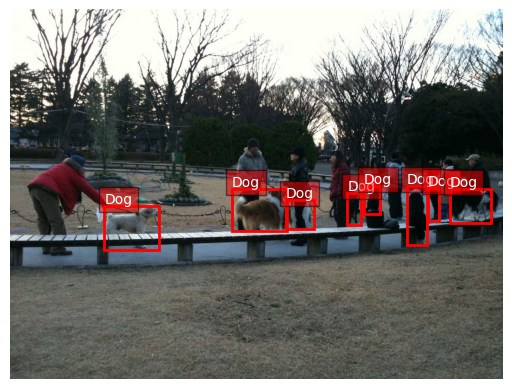

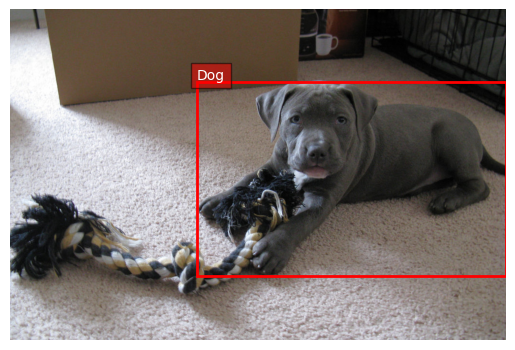

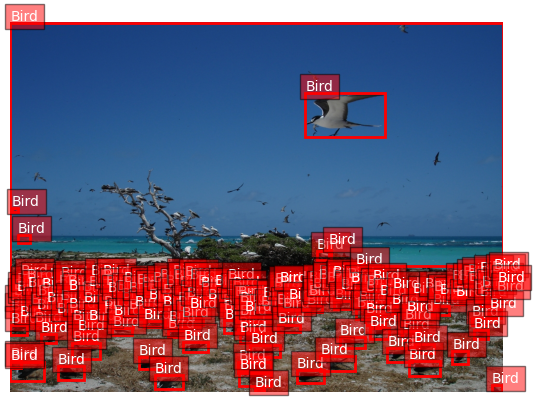

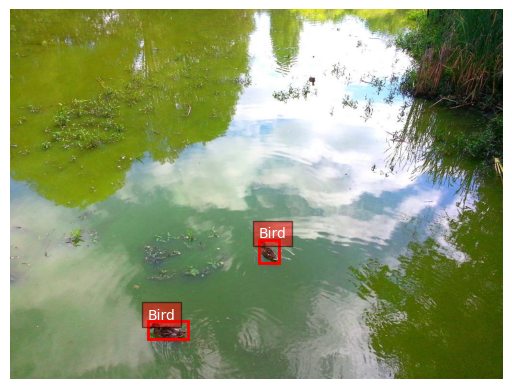

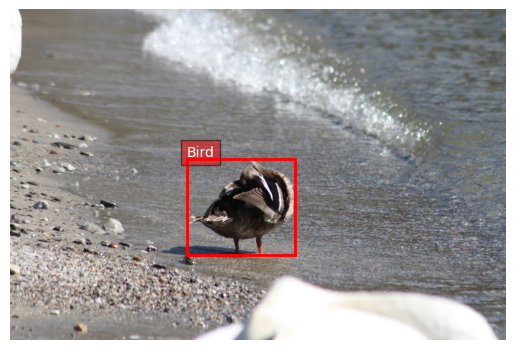

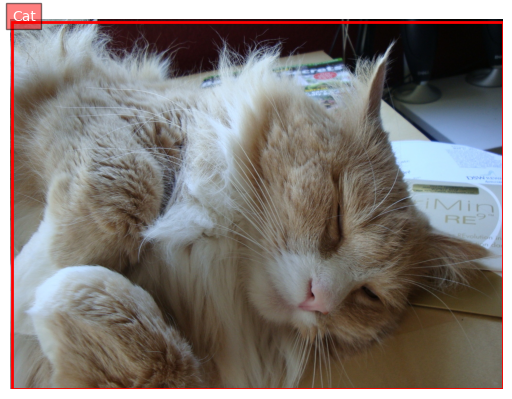

In [8]:
for sample in dataset[:10]:
    show_sample(sample)
